simple linear regression

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/GrandmaCan/ML/main/Resgression/Salary_Data.csv"

data = pd.read_csv(url)
# y=w*x+b
x = data["YearsExperience"]
y = data["Salary"]


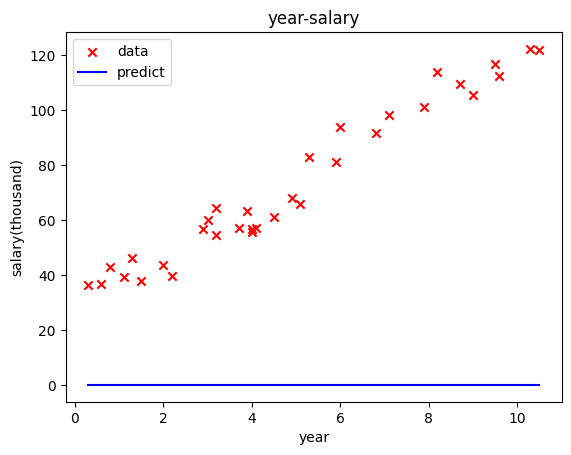

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x,y ,marker="x", color="red", label="data")
plt.title("year-salary")
plt.xlabel("year")
plt.ylabel("salary(thousand)")


# y=w*x+b
w=0
b=0
y_pred=w*x+b
plt.plot(x,y_pred,color="blue",label="predict")
plt.legend() #搭配label顯示圖例
plt.show()


In [ ]:
#改成fun 輸入w,b
def plot_pred(w,b):
  # y=w*x+b
  y_pred=w*x+b
  plt.plot(x,y_pred,color="blue",label="predict")
  plt.scatter(x,y ,marker="x", color="red", label="data")
  plt.title("year-salary")
  plt.xlabel("year")
  plt.ylabel("salary")
  plt.xlim([0,12])#limit x
  plt.ylim([-60,140])#limit y
  plt.legend()
  plt.show()

#加入互動元件
from ipywidgets import interact
interact(plot_pred, w=(-100,100,1) ,b=(-100,100,1))

interactive(children=(IntSlider(value=0, description='w', min=-100), IntSlider(value=0, description='b', min=-…

<function __main__.plot_pred(w, b)>

cost function

In [ ]:
w=10
b=0
cost=(y-y_pred)**2#計算真實數據與預測值之間的誤差
cost.sum()/len(x)

6040.596363636363

In [ ]:
def compute_cost(x,y,w,b):
  y_pred=w*x+b
  cost=(y-y_pred)**2
  cost = cost.sum() / len(x)

  return cost

In [ ]:
compute_cost(x,y,10,0)

602.547878787879

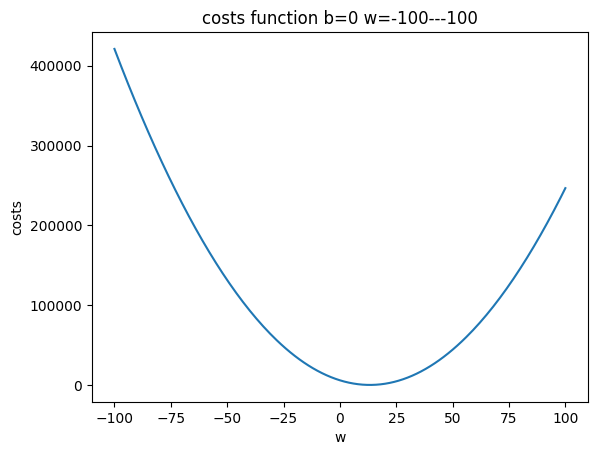

In [ ]:
#b=0 w=-100----100 cost?

costs=[]

for w in range(-100,101):
  cost=compute_cost(x,y,w,0)
  costs.append(cost)

plt.plot(range(-100,101), costs)
plt.title("costs function b=0 w=-100---100")
plt.xlabel("w")
plt.ylabel("costs")
plt.show()

In [ ]:
#b=-100---100 w=-100----100 cost?

import numpy as np

ws = np.arange(-100,101)
bs = np.arange(-100,101)
costs = np.zeros((201,201))

i=0
for w in ws:
  j=0
  for b in bs:
    cost = compute_cost(x, y, w, b)
    costs[i,j] = cost
    j+=1
  i+=1

costs

array([[543097.74787879, 541777.28121212, 540458.81454545, ...,
        320651.34787879, 319726.88121212, 318804.41454545],
       [534727.50939394, 533416.80636364, 532108.10333333, ...,
        314214.30939394, 313299.60636364, 312386.90333333],
       [526422.82181818, 525121.88242424, 523822.9430303 , ...,
        307842.82181818, 306937.88242424, 306034.9430303 ],
       ...,
       [164229.90787879, 164842.64121212, 165457.37454545, ...,
        324557.10787879, 325565.84121212, 326576.57454545],
       [168838.74939394, 169461.24636364, 170085.74333333, ...,
        331099.14939394, 332117.64636364, 333138.14333333],
       [173513.14181818, 174145.40242424, 174779.6630303 , ...,
        337706.74181818, 338735.00242424, 339765.2630303 ]])

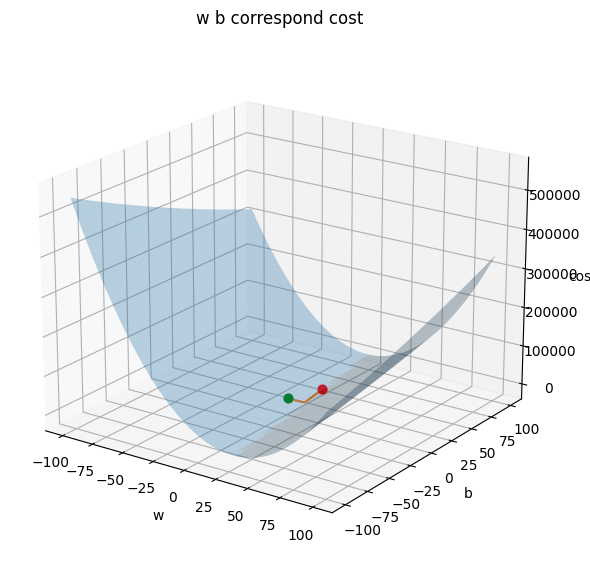

when w=[9], b=[29] find min cost=[32.69484848]


In [ ]:
plt.figure(figsize=(7,7))

ax = plt.axes(projection="3d")#3d graph
ax.view_init(20, -55)#rotation
b_grid, w_grid=np.meshgrid(bs, ws)#網格
ax.plot_surface(w_grid, b_grid, costs,  alpha=0.3)#cmap(colar) 透明度(alpha) # cmap="Spectral_r"
#ax.plot_wireframe(w_grid, b_grid, costs, color="black", alpha=0.1)#加邊框

ax.set_title("w b correspond cost")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("cost")


w_index, b_index = np.where(costs == np.min(costs))#find when w=?,b=? min cost=?

ax.scatter(ws[w_index], bs[b_index], costs[w_index, b_index], color="red", s=40)

ax.scatter(w_hist[0], b_hist[0], c_hist[0], color="green", s=40)
ax.plot(w_hist, b_hist, c_hist)

plt.show()
print(f"when w={ws[w_index]}, b={bs[b_index]} find min cost={costs[w_index, b_index]}")




gradient_descent

In [ ]:

def compute_gradient(x, y, w, b):
  w_gradient = (2*x*(w*x+b -y)).mean()
  b_gradient = (2*(w*x+b -y)).mean()

  return  w_gradient, b_gradient

In [ ]:
compute_gradient(x, y, 20, 10)

(537.0951515151515, 70.16969696969697)

In [ ]:

def gradient_descent(x, y, w_init, b_init, learning_rate, cost_function, gradient_function, run_iter, p_iter=1000):

  w_hist=[]
  b_hist=[]
  c_hist=[]

  w = w_init
  b = b_init

  for i in range(run_iter):
    w_gradient, b_gradient = gradient_function(x, y, w, b)
    w = w - w_gradient*learning_rate
    b = b - b_gradient*learning_rate
    cost = cost_function(x, y, w, b)
    w_hist.append(w)
    b_hist.append(b)
    c_hist.append(cost)
    if i % p_iter == 0:
      print(f"Iteration: {i:5}, cost: {cost: .4e}, w: {w: .2e}, b: {b: .2e}, w_gradient: {w_gradient: .2e}, b_gradient: {b_gradient: .2e}")
  return w, b, w_hist, b_hist, c_hist

In [ ]:
w = 0
b = 0
learning_rate = 0.001

w_final, b_final, w_hist, b_hist, c_hist = gradient_descent(x, y, w, b, learning_rate, compute_cost, compute_gradient, 20000)







Iteration:     0, cost:  5.2861e+03, w:  8.72e-01, b:  1.45e-01, w_gradient: -8.72e+02, b_gradient: -1.45e+02
Iteration:  1000, cost:  9.6020e+01, w:  1.14e+01, b:  1.27e+01, w_gradient:  1.22e+00, b_gradient: -8.15e+00
Iteration:  2000, cost:  5.4275e+01, w:  1.05e+01, b:  1.91e+01, w_gradient:  7.18e-01, b_gradient: -4.78e+00
Iteration:  3000, cost:  3.9926e+01, w:  9.91e+00, b:  2.28e+01, w_gradient:  4.21e-01, b_gradient: -2.80e+00
Iteration:  4000, cost:  3.4993e+01, w:  9.59e+00, b:  2.49e+01, w_gradient:  2.47e-01, b_gradient: -1.64e+00
Iteration:  5000, cost:  3.3298e+01, w:  9.39e+00, b:  2.62e+01, w_gradient:  1.45e-01, b_gradient: -9.63e-01
Iteration:  6000, cost:  3.2715e+01, w:  9.28e+00, b:  2.70e+01, w_gradient:  8.48e-02, b_gradient: -5.65e-01
Iteration:  7000, cost:  3.2515e+01, w:  9.22e+00, b:  2.74e+01, w_gradient:  4.97e-02, b_gradient: -3.31e-01
Iteration:  8000, cost:  3.2446e+01, w:  9.18e+00, b:  2.76e+01, w_gradient:  2.92e-02, b_gradient: -1.94e-01
Iteration:

Text(0, 0.5, 'cost')

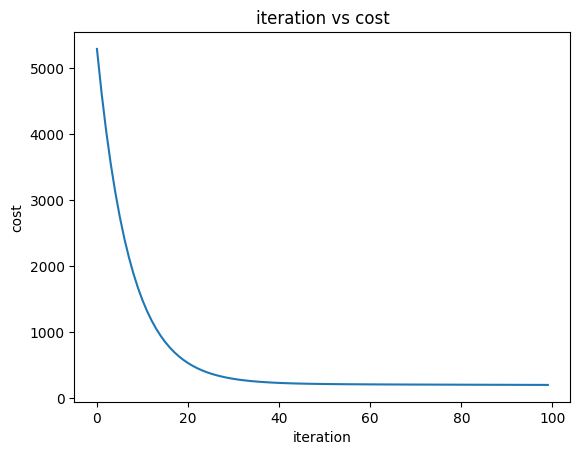

In [ ]:
plt.plot(np.arange(0,100), c_hist[:100])

plt.title("iteration vs cost")
plt.xlabel("iteration")
plt.ylabel("cost")

In [ ]:
print(f"final w={w_final:.2f}, b={b_final:.2f}")

final w=9.12, b=28.01


In [ ]:
print(f"year: 3.5yr salary:{w_final * 3.5 + b_final:.1f}k")
print(f"year: 5.9yr salary:{w_final * 5.9 + b_final:.1f}k")

year: 3.5yr salary:59.9k
year: 5.9yr salary:81.8k


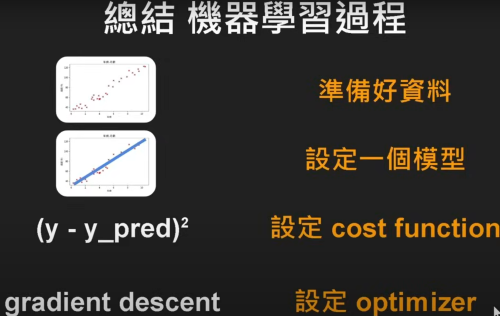